In [2]:
import pandas as pd
import os
import numpy as np
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from dataset import StrictMonotonicCKF


# --- 1. FIT GLOBAL PCA (dari semua file sekaligus) ---
def fit_global_pca(file_list, scenarios):
    """
    Fit satu StandardScaler + PCA per scenario menggunakan data gabungan
    dari semua file. Kembalikan dict berisi scaler & pca yang sudah fit.
    """
    fitted = {}

    for scenario_name, cols in scenarios.items():
        print(f"\n--- Fitting global PCA for [{scenario_name}] ---")
        all_features = []

        for file_path in file_list:
            if not os.path.exists(file_path):
                continue
            df = pd.read_csv(file_path)
            df = df.interpolate(method='linear').ffill().bfill()
            available_cols = [c for c in cols if c in df.columns]
            if not available_cols:
                continue
            all_features.append(df[available_cols].values)

        if not all_features:
            print(f"  Tidak ada data untuk scenario [{scenario_name}]")
            continue

        combined = np.vstack(all_features)

        scaler = StandardScaler()
        scaled = scaler.fit_transform(combined)

        pca = PCA(n_components=1)
        pca.fit(scaled)

        explained_var = pca.explained_variance_ratio_[0] * 100
        print(f"  Explained variance (PC1): {explained_var:.2f}%")

        # Simpan artifact
        joblib.dump(scaler, f'scaler_std_{scenario_name}.pkl')
        joblib.dump(pca,    f'pca_{scenario_name}.pkl')
        print(f"  Saved: scaler_std_{scenario_name}.pkl | pca_{scenario_name}.pkl")

        fitted[scenario_name] = {'scaler': scaler, 'pca': pca, 'cols': cols}

    return fitted


# --- 2. TRANSFORM TIAP FILE MENGGUNAKAN GLOBAL PCA ---
def transform_files(file_list, fitted, output_dir):
    """
    Terapkan global scaler+PCA ke tiap file, jalankan CKF filter,
    lalu simpan hasilnya ke output_dir.
    """
    output_files = []

    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"File tidak ditemukan, dilewati: {file_path}")
            continue

        print(f"\nTransforming: {file_path}")
        df_raw = pd.read_csv(file_path)
        df_filled = df_raw.interpolate(method='linear').ffill().bfill()
        pca_results = pd.DataFrame(index=df_raw.index)

        for scenario_name, artifacts in fitted.items():
            scaler = artifacts['scaler']
            pca    = artifacts['pca']
            cols   = artifacts['cols']

            available_cols = [c for c in cols if c in df_filled.columns]
            if not available_cols:
                continue

            features = df_filled[available_cols].values
            scaled   = scaler.transform(features)
            pc1_raw  = pca.transform(scaled).flatten()

            pca_results[f"PC1_Raw_{scenario_name}"] = pc1_raw

            ckf = StrictMonotonicCKF(initial_value=pc1_raw[0], meas_var=15.0)
            pc1_filtered = np.array([ckf.process(v) for v in pc1_raw])
            pca_results[f"PC1_{scenario_name}"] = pc1_filtered

        file_name   = os.path.basename(file_path)
        out_path    = os.path.join(output_dir, f"PCA_Results_{file_name}")
        pca_results.to_csv(out_path, index=False)
        output_files.append(out_path)
        print(f"  Saved: {out_path}")

    return output_files


# --- 3. FIT & TERAPKAN GLOBAL MINMAX ---
def fit_and_apply_global_minmax(output_files, scenarios_to_normalize):
    """
    Fit MinMaxScaler dari semua output file (global), lalu overwrite
    setiap file dengan nilai ternormalisasi. Scaler disimpan ke .pkl.
    """
    scalers = {}

    for scenario in scenarios_to_normalize:
        col = f"PC1_{scenario}"
        print(f"\n--- Global MinMax untuk [{scenario}] ---")
        all_values = []
        valid_files = []

        for f in output_files:
            df = pd.read_csv(f)
            if col in df.columns:
                all_values.append(df[col].values)
                valid_files.append(f)

        if not all_values:
            print(f"  Kolom {col} tidak ditemukan.")
            continue

        combined = np.concatenate(all_values).reshape(-1, 1)
        minmax   = MinMaxScaler(feature_range=(0, 1))
        minmax.fit(combined)

        for f in valid_files:
            df = pd.read_csv(f)
            df[col] = minmax.transform(df[col].values.reshape(-1, 1))
            df.to_csv(f, index=False)
            print(f"  Normalized & overwritten: {f}")

        joblib.dump(minmax, f'scaler_minmax_{scenario}.pkl')
        print(f"  Saved: scaler_minmax_{scenario}.pkl")
        scalers[scenario] = minmax

    return scalers


# --- 4. MAIN ---
data_dir = r"Plot Data\Dirty Data"

if not os.path.exists(data_dir):
    print(f"Direktori tidak ditemukan: {data_dir}")
else:
    cyl_cols     = [f'Exh Cyl #{i} Temp' for i in range(1, 7)]
    support_cols = ['Exh Right Temp', 'Exh Left Temp', 'Oil Temp', 'JW Temp']

    scenarios = {
        'Combustion': cyl_cols,
        'Systemic':   support_cols,
        'Global':     cyl_cols + support_cols,
    }

    input_files = [
        os.path.join(data_dir, f'run_to_failure{i}_pad.csv')
        for i in range(1, 8)
    ]

    # Step 1 — fit PCA secara global
    fitted_artifacts = fit_global_pca(input_files, scenarios)

    # Step 2 — transform tiap file & simpan CSV
    output_files = transform_files(input_files, fitted_artifacts, data_dir)

    # Step 3 — fit MinMax secara global & normalisasi
    if output_files:
        fit_and_apply_global_minmax(
            output_files,
            scenarios_to_normalize=['Combustion', 'Systemic', 'Global']
        )

    print("\n--- Proses Selesai ---")
    print("\nArtifact yang tersimpan:")
    for s in scenarios:
        print(f"  scaler_std_{s}.pkl   — StandardScaler untuk PCA")
        print(f"  pca_{s}.pkl          — PCA model")
        print(f"  scaler_minmax_{s}.pkl — MinMaxScaler (0–1)")


--- Fitting global PCA for [Combustion] ---
  Explained variance (PC1): 88.17%
  Saved: scaler_std_Combustion.pkl | pca_Combustion.pkl

--- Fitting global PCA for [Systemic] ---
  Explained variance (PC1): 54.91%
  Saved: scaler_std_Systemic.pkl | pca_Systemic.pkl

--- Fitting global PCA for [Global] ---
  Explained variance (PC1): 69.23%
  Saved: scaler_std_Global.pkl | pca_Global.pkl

Transforming: Plot Data\Dirty Data\run_to_failure1_pad.csv
  Saved: Plot Data\Dirty Data\PCA_Results_run_to_failure1_pad.csv

Transforming: Plot Data\Dirty Data\run_to_failure2_pad.csv
  Saved: Plot Data\Dirty Data\PCA_Results_run_to_failure2_pad.csv

Transforming: Plot Data\Dirty Data\run_to_failure3_pad.csv
  Saved: Plot Data\Dirty Data\PCA_Results_run_to_failure3_pad.csv

Transforming: Plot Data\Dirty Data\run_to_failure4_pad.csv
  Saved: Plot Data\Dirty Data\PCA_Results_run_to_failure4_pad.csv

Transforming: Plot Data\Dirty Data\run_to_failure5_pad.csv
  Saved: Plot Data\Dirty Data\PCA_Results_run_

In [2]:
import os
import torch
import json
from tuner import OptunaTuner

# --- KONFIGURASI ---
DIRS = {
    'Dirty': 'Plot Data/Dirty Data/',
    'Clean': 'Plot Data/Clean Data/',
}

VARIATIONS  = ['Combustion', 'Systemic', 'Global']

TRAIN_FILES = [
    'PCA_Results_run_to_failure1_pad.csv',
    'PCA_Results_run_to_failure2_pad.csv',
    'PCA_Results_run_to_failure5_pad.csv',
    'PCA_Results_run_to_failure6_pad.csv',
    'PCA_Results_run_to_failure7_pad.csv',
]
VAL_FILES = [
    'PCA_Results_run_to_failure3_pad.csv',
]

HYPER_SPACE = {
    "hidden_dim" : (32, 128, 16),
    "lr"         : (0.0001, 0.1),
    "window_size": (5, 50, 5),
}

N_TRIALS = 100
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

# --- OUTPUT FOLDER ---
output_dir = 'Training Results'
os.makedirs(output_dir, exist_ok=True)

# --- MAIN LOOP ---
all_best_params = {}  # Menyimpan semua hasil untuk ditulis ke txt

for data_type, data_dir in DIRS.items():
    print(f"\n{'='*60}")
    print(f"  DATA TYPE : {data_type}")
    print(f"  DIR       : {data_dir}")
    print(f"{'='*60}")

    all_best_params[data_type] = {}

    for variation in VARIATIONS:
        print(f"\n--- Variation: {variation} ---")

        train_files = [os.path.join(data_dir, f) for f in TRAIN_FILES]
        val_files   = [os.path.join(data_dir, f) for f in VAL_FILES]

        # Cek file tersedia
        missing = [f for f in train_files + val_files if not os.path.exists(f)]
        if missing:
            print(f"  [SKIP] File tidak ditemukan:")
            for m in missing:
                print(f"    - {m}")
            continue

        tuner = OptunaTuner(
            train_files = train_files,
            val_files   = val_files,
            variation   = variation,
            device      = device,
            hyper_space = HYPER_SPACE,
            val_mode='rul',
        )

        study = tuner.run(n_trials=N_TRIALS)

        # Rename model yang disimpan agar tidak tertimpa antar variasi/data_type
        src_model = f"BiLSTM_{variation}_best.pt"
        dst_model = os.path.join(output_dir, f"BiLSTM_{data_type}_{variation}_best.pt")
        if os.path.exists(src_model):
            os.replace(src_model, dst_model)
            print(f"  Model disimpan: {dst_model}")

        # Simpan best params
        all_best_params[data_type][variation] = {
            'best_params' : study.best_params,
            'best_value'  : round(study.best_value, 4),
            'model_file'  : dst_model,
        }

# --- TULIS HASIL KE TXT ---
txt_path = os.path.join(output_dir, 'best_configs.txt')
with open(txt_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("  BEST HYPERPARAMETER CONFIGURATIONS\n")
    f.write("=" * 60 + "\n\n")

    for data_type, variations in all_best_params.items():
        f.write(f"[{data_type}]\n")
        f.write("-" * 40 + "\n")
        for variation, info in variations.items():
            f.write(f"  Variation   : {variation}\n")
            f.write(f"  Best Value  : {info['best_value']}\n")
            f.write(f"  Model File  : {info['model_file']}\n")
            f.write(f"  Params      :\n")
            for k, v in info['best_params'].items():
                f.write(f"    {k:15s}: {v}\n")
            f.write("\n")
        f.write("\n")

# Juga simpan sebagai JSON untuk kemudahan load programatik
json_path = os.path.join(output_dir, 'best_configs.json')
with open(json_path, 'w') as f:
    json.dump(all_best_params, f, indent=2)

print(f"\n{'='*60}")
print(f"  Semua training selesai!")
print(f"  Hasil disimpan di: {output_dir}/")
print(f"    - best_configs.txt  (human-readable)")
print(f"    - best_configs.json (machine-readable)")
print(f"{'='*60}")

[I 2026-04-29 09:40:06,526] A new study created in memory with name: no-name-ac17fed1-8ab0-403c-9066-6f626475227e


Device: cuda


  DATA TYPE : Dirty
  DIR       : Plot Data/Dirty Data/

--- Variation: Combustion ---

=== Optuna Tuning | variation=Combustion | val_mode=rul ===
  Epoch   0 | MSE = 0.025287
  Epoch  10 | MSE = 0.000010
    [flatline] 0/1 files flat → OK ✓


[I 2026-04-29 09:40:09,323] Trial 0 finished with value: 0.07801515037239297 and parameters: {'hidden_dim': 48, 'lr': 0.006511035930626417, 'window_size': 25}. Best is trial 0 with value: 0.07801515037239297.


    [eval] MSE=0.000130 | RUL_err=155.9 | Score=0.078015
Trial 0 | Window=25 | Hidden=48 | lr=6.51e-03 | Score=0.078015 | mode=rul
  Epoch   0 | MSE = 0.115459
  Epoch  10 | MSE = 0.000028
    [flatline] 1/1 files flat → FLATLINE ✗
    [flatline] Penalized score: 1.001460


[I 2026-04-29 09:40:12,133] Trial 1 finished with value: 5.4869801315199584 and parameters: {'hidden_dim': 32, 'lr': 0.0010559438935077705, 'window_size': 50}. Best is trial 0 with value: 0.07801515037239297.


...

    [eval] MSE=0.000021 | RUL_err=1993.5 | Score=0.996761
Trial 97 | Window=20 | Hidden=80 | lr=2.52e-02 | Score=0.996761 | mode=rul
  Epoch   0 | MSE = 0.067904
  Epoch  10 | MSE = 0.005215
    [flatline] 1/1 files flat → FLATLINE ✗
    [flatline] Penalized score: 1.000073


[I 2026-04-29 10:29:24,905] Trial 98 finished with value: 5.481936378849472 and parameters: {'hidden_dim': 64, 'lr': 0.041267943149190744, 'window_size': 20}. Best is trial 88 with value: 0.0009061024361457383.


    [eval] MSE=1.000073 | RUL_err=9963.8 | Score=5.481936
Trial 98 | Window=20 | Hidden=64 | lr=4.13e-02 | Score=5.481936 | mode=rul
  Epoch   0 | MSE = 0.021886
  Epoch  10 | MSE = 0.000004
    [flatline] 1/1 files flat → FLATLINE ✗
    [flatline] Penalized score: 1.000081


[I 2026-04-29 10:29:30,283] Trial 99 finished with value: 5.482440515995351 and parameters: {'hidden_dim': 80, 'lr': 0.030845057259325286, 'window_size': 25}. Best is trial 88 with value: 0.0009061024361457383.


    [eval] MSE=1.000081 | RUL_err=9964.8 | Score=5.482441
Trial 99 | Window=25 | Hidden=80 | lr=3.08e-02 | Score=5.482441 | mode=rul

Best Params: {'hidden_dim': 80, 'lr': 0.05573901813050361, 'window_size': 25}
  Epoch   0 | MSE = 0.882279
  Epoch  10 | MSE = 0.036371
  Epoch  20 | MSE = 0.000051
  Epoch  30 | MSE = 0.002155
  Epoch  40 | MSE = 0.000044

Model disimpan: BiLSTM_Global_best.pt
  Model disimpan: Training Results\BiLSTM_Clean_Global_best.pt

  Semua training selesai!
  Hasil disimpan di: Training Results/
    - best_configs.txt  (human-readable)
    - best_configs.json (machine-readable)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_24368\3344672336.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1, 1))


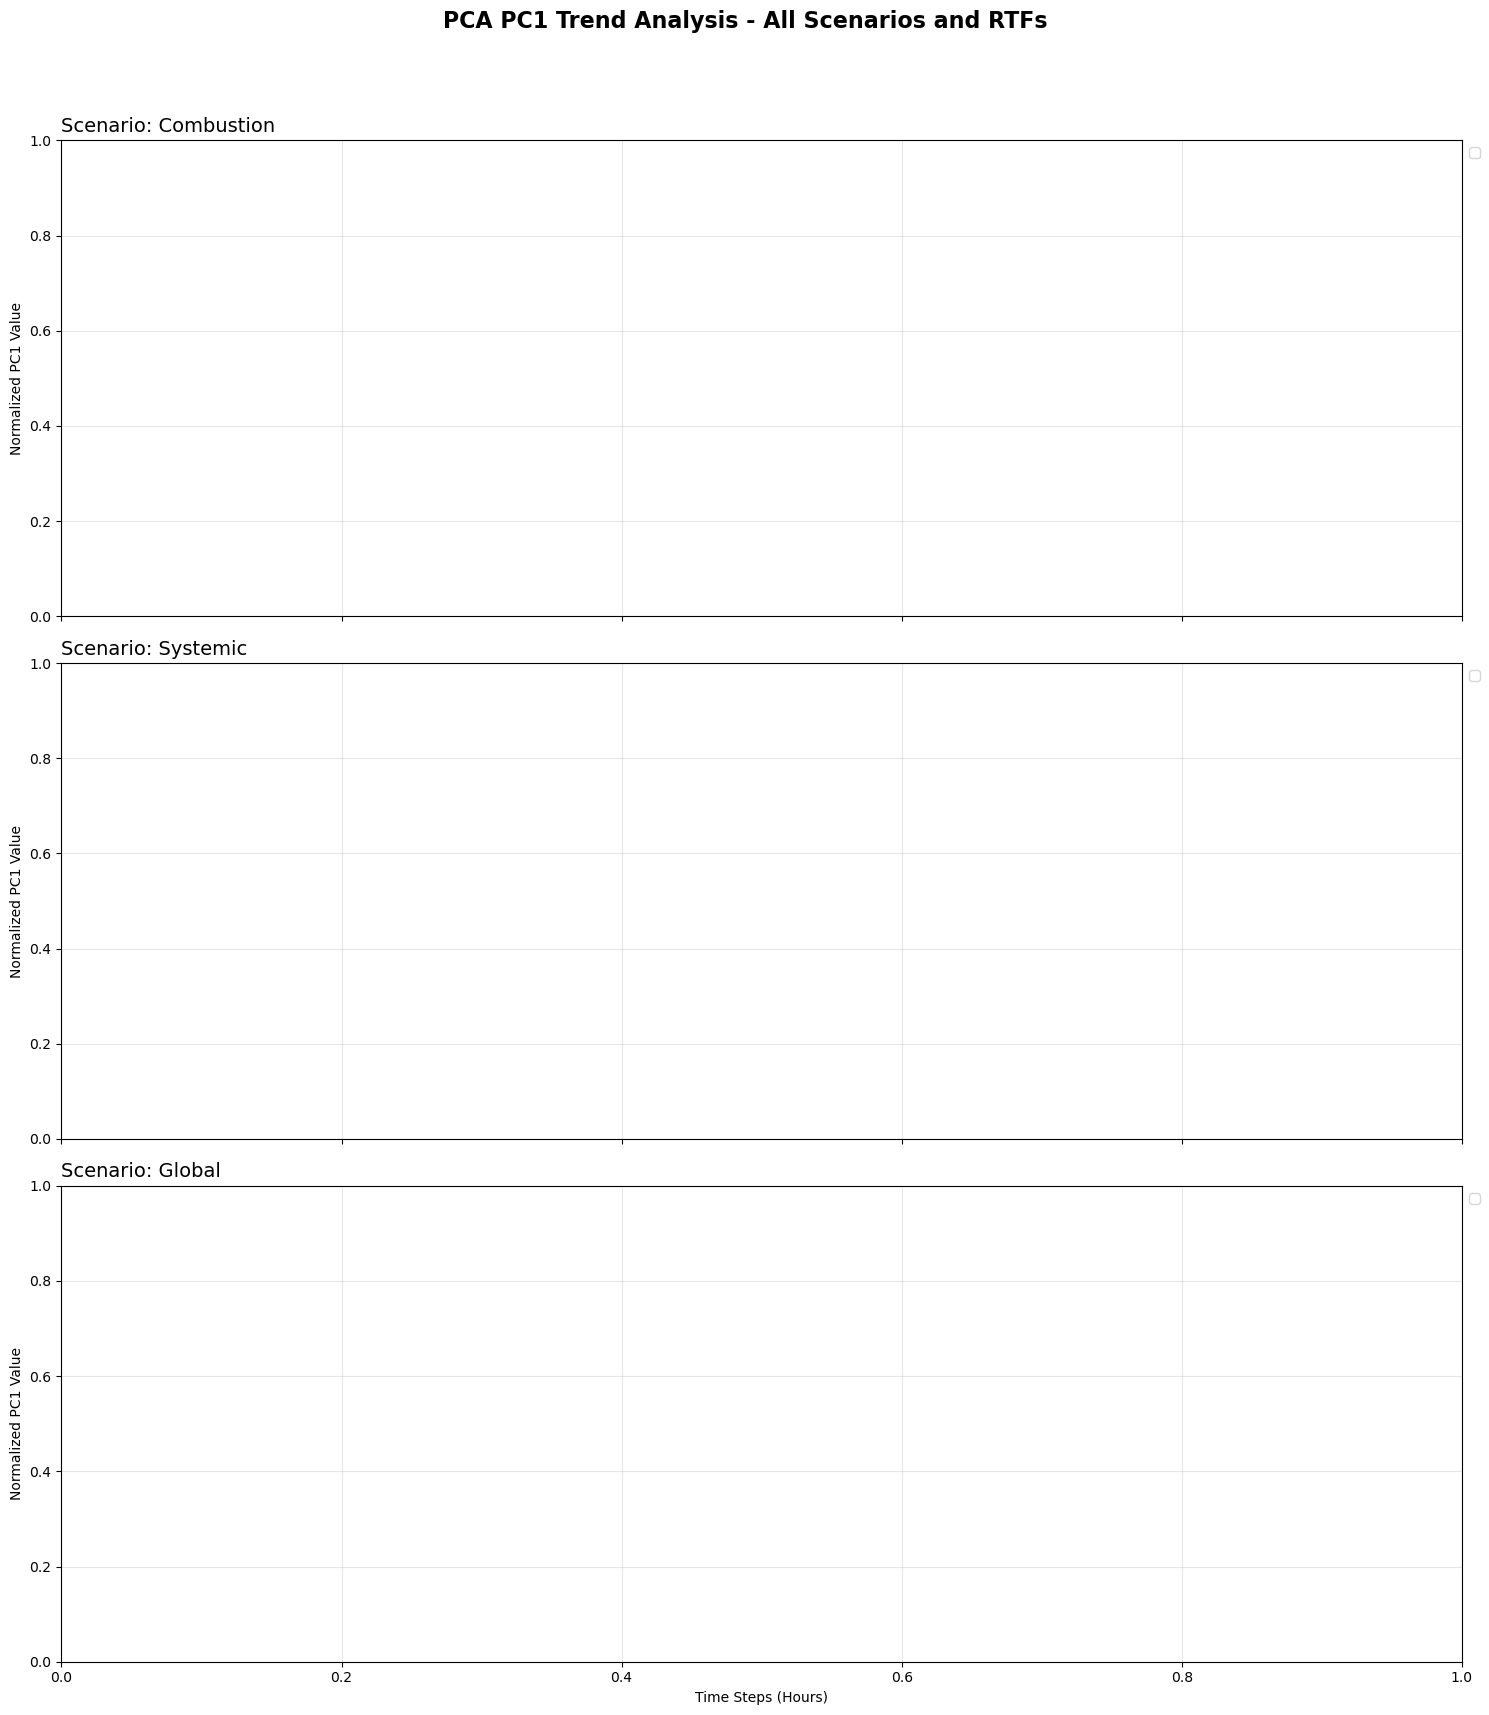

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_all_scenarios(file_list):
    scenarios = ['Combustion', 'Systemic', 'Global']
    colors = ['#1f77b4', '#ff7f0e', "#1aab1a", '#d62728', '#9467bd']

    fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)
    fig.suptitle('PCA PC1 Trend Analysis - All Scenarios and RTFs', fontsize=16, fontweight='bold')

    for i, scenario in enumerate(scenarios):
        column_name = f"PC1_{scenario}"
        ax = axes[i]

        for idx, file_path in enumerate(file_list):
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                rtf_label = file_path.replace('PCA_Results_', '').replace('.csv', '')
                ax.plot(df[column_name], label=rtf_label, color=colors[idx % len(colors)], alpha=0.8)

        ax.set_title(f'Scenario: {scenario}', fontsize=14, loc='left')
        ax.set_ylabel('Normalized PC1 Value')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.xlabel('Time Steps (Hours)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('All_Scenarios_Comparison.png', dpi=300)
    plt.show()

output_files = [f"PCA_Results_run_to_failure{i}.csv" for i in range(1, 8)]
plot_all_scenarios(output_files)


<>:12: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:12: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\LOQ\AppData\Local\Temp\ipykernel_24368\3159373942.py:12: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  VAL_FILE = 'Plot Data\Dirty Data\PCA_Results_run_to_failure7.csv'


--- Loading Best Model from BiLSTM_Global_best.pt ---
--- Creating Collapsed Model (Simulating Trial 123) ---
Simulating RUL...
PoC Result saved as 'PoC_RUL_Verification.png'


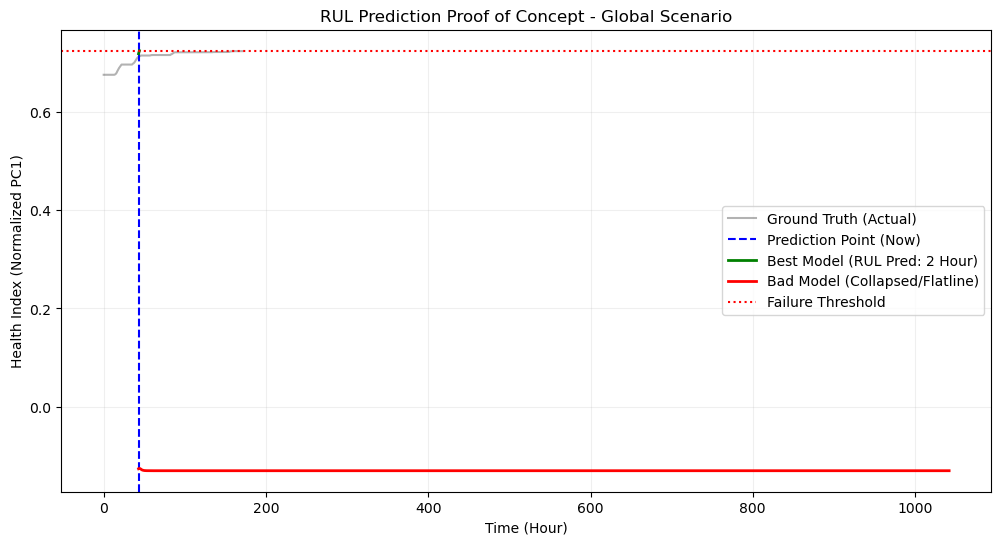

In [ ]:
import torch
import pandas as pd
from model_train import BiLSTM
import numpy as np
import matplotlib.pyplot as plt

VARIATION = 'Global'
BEST_MODEL_PATH = f"BiLSTM_{VARIATION}_best.pt"
VAL_FILE = 'Plot Data\\Dirty Data\\PCA_Results_run_to_failure7.csv'
BEST_PARAMS = {'hidden_dim': 32, 'window_size': 36}
BAD_PARAMS = {'hidden_dim': 32, 'window_size': 14, 'lr': 0.0014517193218636021}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def create_bad_model():
    print("--- Creating Collapsed Model (Simulating Trial 123) ---")
    model = BiLSTM(1, BAD_PARAMS['hidden_dim'], 1).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=BAD_PARAMS['lr'])
    criterion = torch.nn.MSELoss()
    x_dummy = torch.randn(10, BAD_PARAMS['window_size'], 1).to(DEVICE)
    y_dummy = torch.randn(10, 1).to(DEVICE)

    for _ in range(5):
        optimizer.zero_grad()
        loss = criterion(model(x_dummy), y_dummy)
        loss.backward()
        optimizer.step()
    return model

def rollout(model, seed_seq, threshold, max_steps=1000):
    model.eval()
    seq = seed_seq.clone().detach().to(DEVICE)
    preds = []

    for _ in range(max_steps):
        with torch.no_grad():
            out = model(seq.unsqueeze(0)).item()
        preds.append(out)
        new_val = torch.tensor([[out]], device=DEVICE)
        seq = torch.cat([seq[1:], new_val], dim=0)
        if out >= threshold:
            break
    return preds

def run_proof_of_concept():
    df = pd.read_csv(VAL_FILE)
    series = df[f"PC1_{VARIATION}"].values.astype(np.float32)
    threshold = series[-1]
    split_idx = int(len(series) * 0.25)
    seed_data = series[split_idx - BEST_PARAMS['window_size']: split_idx]
    seed_tensor = torch.from_numpy(seed_data).unsqueeze(-1)

    print(f"--- Loading Best Model from {BEST_MODEL_PATH} ---")
    best_model = BiLSTM(1, BEST_PARAMS['hidden_dim'], 1).to(DEVICE)
    best_model.load_state_dict(torch.load(BEST_MODEL_PATH))

    bad_model = create_bad_model()
    print("Simulating RUL...")
    preds_best = rollout(best_model, seed_tensor, threshold)
    preds_bad = rollout(bad_model, seed_tensor, threshold)

    plt.figure(figsize=(12, 6))
    plt.plot(range(len(series)), series, color='black', label='Ground Truth (Actual)', alpha=0.3)
    plt.axvline(x=split_idx, color='blue', linestyle='--', label='Prediction Point (Now)')
    time_best = range(split_idx, split_idx + len(preds_best))
    plt.plot(time_best, preds_best, color='green', linewidth=2, label=f'Best Model (RUL Pred: {len(preds_best)} Hour)')
    time_bad = range(split_idx, split_idx + len(preds_bad))
    plt.plot(time_bad, preds_bad, color='red', linewidth=2, label='Bad Model (Collapsed/Flatline)')
    plt.axhline(y=threshold, color='red', linestyle=':', label='Failure Threshold')
    plt.title(f'RUL Prediction Proof of Concept - {VARIATION} Scenario')
    plt.xlabel('Time (Hour)')
    plt.ylabel('Health Index (Normalized PC1)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig('PoC_RUL_Verification.png', dpi=300)
    print("PoC Result saved as 'PoC_RUL_Verification.png'")
    plt.show()

if __name__ == "__main__":
    run_proof_of_concept()


--- Loading Model: BiLSTM_Global_best.pt ---
--- Simulating RUL for Residual Analysis ---

[HASIL STATISTIK]
Mean Residual: -49.00 Jam
Std Deviation: 42.78
Shapiro-Wilk: Stat=0.9662, p-value=0.8659


C:\Users\LOQ\AppData\Local\Temp\ipykernel_24660\2309554168.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Phase', y='Error', data=pd.DataFrame(plot_df), ax=ax3, palette='Set2')



--- Analisis Selesai! Grafik disimpan di: Final_Proof_of_Concept_Normality.png ---


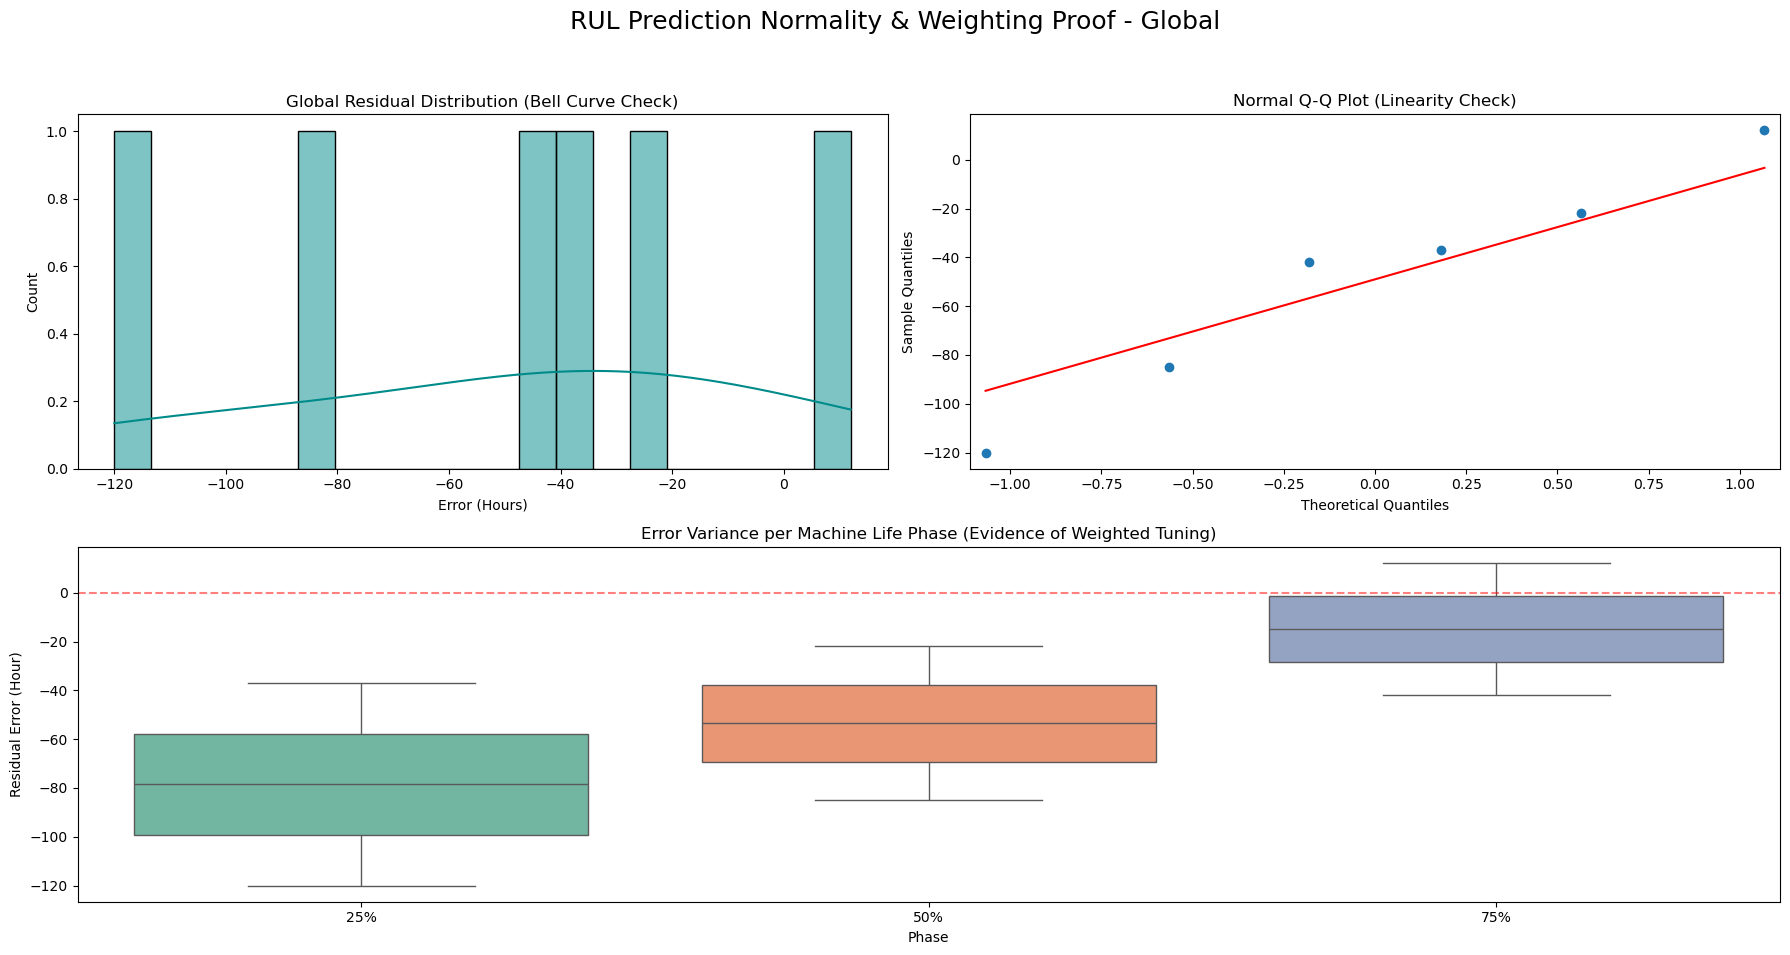

In [8]:
import torch
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from model_train import BiLSTM
import os
import matplotlib.pyplot as plt

# Memastikan arsitektur BiLSTM terbaca
# =========================================================
# 1. PARAMETER - SESUAIKAN DENGAN HASIL TUNING ANDA
# =========================================================
CONFIG = {
    "variation": "Global",
    "model_path": "BiLSTM_Global_best.pt",
    "val_files": [
        "PCA_Results_run_to_failure6.csv",
        "PCA_Results_run_to_failure7.csv" 
    ],
    "window_size": 17,  # Ganti dengan best window_size Anda
    "hidden_dim": 24,   # Ganti dengan best hidden_dim Anda
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

# =========================================================
# 2. FUNGSI ROLLOUT (SIMULASI PREDIKSI)
# =========================================================
def simulate_rul(model, seed_seq, threshold, device, max_steps=2000):
    model.eval()
    current_seq = seed_seq.clone().detach().to(device)
    steps_predicted = 0
    
    while steps_predicted < max_steps:
        with torch.no_grad():
            # Input shape: (1, window_size, 1)
            prediction = model(current_seq.unsqueeze(0)).item()
        
        # Update Sliding Window
        new_entry = torch.tensor([[prediction]], device=device)
        current_seq = torch.cat([current_seq[1:], new_entry], dim=0)
        
        steps_predicted += 1
        if prediction >= threshold:
            break
            
    return steps_predicted

# =========================================================
# 3. MAIN ANALYSIS SCRIPT
# =========================================================
def run_full_normality_test():
    # A. Validasi keberadaan file
    if not os.path.exists(CONFIG["model_path"]):
        print(f"Error: Model '{CONFIG['model_path']}' tidak ditemukan!")
        return

    # B. Load Model
    print(f"--- Loading Model: {CONFIG['model_path']} ---")
    model = BiLSTM(1, CONFIG["hidden_dim"], 1).to(CONFIG["device"])
    model.load_state_dict(torch.load(CONFIG["model_path"], map_location=CONFIG["device"]))
    model.eval()

    residuals_data = {"25%": [], "50%": [], "75%": []}
    target_col = f"PC1_{CONFIG['variation']}"

    # C. Loop Data Validasi
    print("--- Simulating RUL for Residual Analysis ---")
    for file_name in CONFIG["val_files"]:
        if not os.path.exists(file_name):
            print(f"Warning: File {file_name} tidak ditemukan, skipping...")
            continue
            
        df = pd.read_csv(file_name)
        series = df[target_col].values.astype(np.float32)
        total_length = len(series)
        fail_threshold = series[-1]

        for label, pct in [("25%", 0.25), ("50%", 0.50), ("75%", 0.75)]:
            idx = int(total_length * pct)
            if idx < CONFIG["window_size"]: idx = CONFIG["window_size"]
            
            # Ambil sejarah (seed)
            seed = series[idx - CONFIG["window_size"] : idx]
            seed_tensor = torch.from_numpy(seed).unsqueeze(-1)
            
            true_rul = total_length - idx
            pred_rul = simulate_rul(model, seed_tensor, fail_threshold, CONFIG["device"])
            
            # Hitung Residual (Prediksi - Aktual)
            res = pred_rul - true_rul
            residuals_data[label].append(res)

    # D. Flatten Data untuk Uji Global
    all_res = []
    for k in residuals_data: all_res.extend(residuals_data[k])
    
    if not all_res:
        print("Error: Tidak ada data residual yang berhasil dihitung.")
        return

    # E. Statistik Deskriptif & Shapiro-Wilk
    stat, p_val = stats.shapiro(all_res)
    print(f"\n[HASIL STATISTIK]")
    print(f"Mean Residual: {np.mean(all_res):.2f} Jam")
    print(f"Std Deviation: {np.std(all_res):.2f}")
    print(f"Shapiro-Wilk: Stat={stat:.4f}, p-value={p_val:.4f}")
    
    # F. Visualisasi Terpadu
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2)

    # 1. Distribution & KDE
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(all_res, kde=True, ax=ax1, color='darkcyan', bins=20)
    ax1.set_title('Global Residual Distribution (Bell Curve Check)')
    ax1.set_xlabel('Error (Hours)')

    # 2. Q-Q Plot
    ax2 = fig.add_subplot(gs[0, 1])
    qqplot(np.array(all_res), line='s', ax=ax2)
    ax2.set_title('Normal Q-Q Plot (Linearity Check)')

    # 3. Comparison per Phase (BOXPLOT)
    ax3 = fig.add_subplot(gs[1, :])
    plot_df = []
    for phase, values in residuals_data.items():
        for v in values:
            plot_df.append({"Phase": phase, "Error": v})
    
    sns.boxplot(x='Phase', y='Error', data=pd.DataFrame(plot_df), ax=ax3, palette='Set2')
    ax3.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax3.set_title('Error Variance per Machine Life Phase (Evidence of Weighted Tuning)')
    ax3.set_ylabel('Residual Error (Hour)')

    plt.suptitle(f'RUL Prediction Normality & Weighting Proof - {CONFIG["variation"]}', fontsize=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    output_plot = "Final_Proof_of_Concept_Normality.png"
    plt.savefig(output_plot, dpi=300)
    print(f"\n--- Analisis Selesai! Grafik disimpan di: {output_plot} ---")
    plt.show()

if __name__ == "__main__":
    run_full_normality_test()